In [154]:
# import necessary libraries and set seeds for reproducibility

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
from IPython.display import display, Markdown
from pathlib import Path
import random

random.seed(231)
np.random.seed(231)
ig.set_random_number_generator(random)
output_dir = Path("../figures")
output_dir.mkdir(exist_ok=True, parents=True)




## 1. Data Loading
In this section, we load the Steam network dataset from our JSON file. We inspect the basic structure of the data, which contains `nodes` (games) and `links` (shared reviews between games).

In [155]:
# load the steam network data from json

PATH = "../data/steam_network_full.json"


with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['nodes', 'links', 'meta'])


In [156]:
# extract nodes and links, and print basic stats

nodes = data["nodes"]
links = data["links"]

print("Number of nodes:", len(nodes))
print("Number of links:", len(links))

print("\nFirst node:")
print(nodes[0])

print("\nFirst link:")
print(links[0])

Number of nodes: 25996
Number of links: 861232

First node:
{'id': '1000010', 'title': 'Crown Trick', 'year': '2020', 'rating': 'Very Positive', 'ratio': 85, 'reviews': 5263, 'price': 4.99, 'genres': [3, 0, 6, 5], 'tags': [40, 7], 'developer': 'NEXT Studios'}

First link:
{'source': 19823, 'target': 22447, 'weight': 694377}


### Dataset Metadata
The dataset contains pre-processing metadata that describes how the co-review network was constructed. This information is critical for the **Methods** section of the report.

In [157]:
# display dataset metadata

print("DATASET METADATA\n")
for key, value in data["meta"].items():
    if not isinstance(value, list):
        print(f"  {key}: {value}")


DATASET METADATA

  description: Steam co-review network (128M reviews, 2012-2024)
  node_count: 25996
  link_count: 861232
  min_edge_weight: 5
  max_edge_weight: 694377
  top_k: 50
  min_shared: 5
  max_user_games: 75
  min_game_reviews: 50
  data_source: artermiloff/steam-games-reviews-2024


In [158]:
# check minimum and maximum node indices

source_values = [link["source"] for link in links]
target_values = [link["target"] for link in links]

all_references = source_values + target_values

print("Minimum node reference:", min(all_references))
print("Maximum node reference:", max(all_references))
print("Number of nodes:", len(nodes))

Minimum node reference: 0
Maximum node reference: 25995
Number of nodes: 25996


## 2. Edge Weight Analysis
Here, we extract the weights of the edges (which represent the number of shared reviewers between two games). We calculate basic statistics like the minimum, maximum, mean, and median weights, and plot a logarithmic histogram to visualize the distribution of these weights.

In [159]:
# calculate basic statistics for edge weights

weights = np.array([link["weight"] for link in links])

print(f"Minimum weight: {weights.min():,}")
print(f"Maximum weight: {weights.max():,}")
print(f"Mean weight: {weights.mean():.2f}")
print(f"Median weight: {np.median(weights):.2f}")

Minimum weight: 5
Maximum weight: 694,377
Mean weight: 341.18
Median weight: 27.00


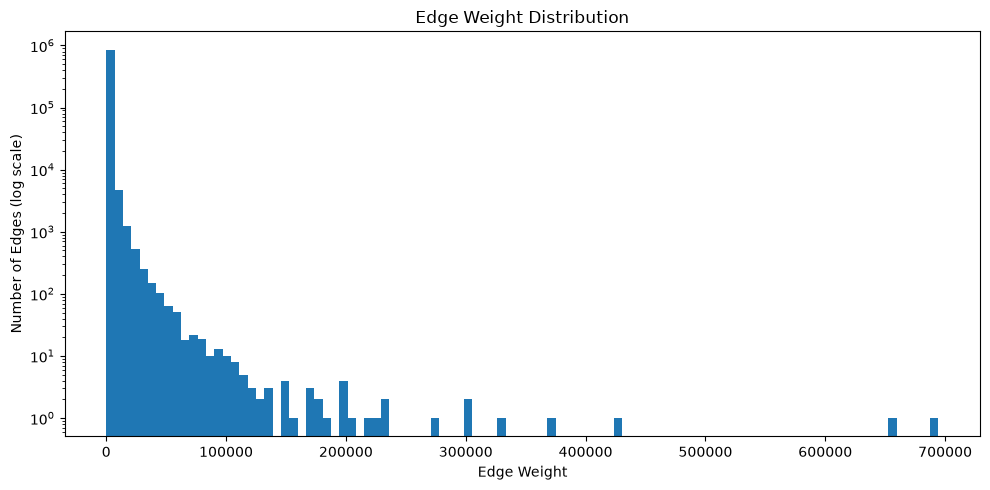

In [160]:
# plot the distribution of edge weights

plt.figure(figsize=(10, 5))
plt.hist(weights, bins=100, log=True)

plt.xlabel("Edge Weight")
plt.ylabel("Number of Edges (log scale)")
plt.title("Edge Weight Distribution")

plt.tight_layout()
plt.show()

In [161]:
# check for self-loops or invalid weights

self_loops = sum(link["source"] == link["target"] for link in links)

print("Self-loops:", self_loops)

missing_weights = sum("weight" not in link for link in links)

print("Links without weight:", missing_weights)

invalid_weights = sum(link["weight"] <= 0 for link in links)

print("Non-positive weights:", invalid_weights)

Self-loops: 0
Links without weight: 0
Non-positive weights: 0


## 3. Graph Construction
We use the `igraph` library to construct our network. The network is modeled as an **undirected graph** since a shared review relationship is mutual. We also assign the weights to the edges and attach metadata (like title, price, reviews) to the vertices (nodes).

In [162]:
# construct the undirected graph using igraph

edges = list(zip(source_values, target_values))

G = ig.Graph(n=len(nodes), edges=edges, directed=False)

G.es["weight"] = weights

print("Graph created successfully.")
print(f"Vertices: {G.vcount():,}")
print(f"Edges: {G.ecount():,}")
print(f"Directed: {G.is_directed()}")
print(f"Edge attributes: {G.es.attributes()}")

Graph created successfully.
Vertices: 25,996
Edges: 861,232
Directed: False
Edge attributes: ['weight']


In [163]:
# assign node attributes like title, price, and reviews

G.vs["id"] = [node["id"] for node in nodes]
G.vs["title"] = [node["title"] for node in nodes]
G.vs["year"] = [node["year"] for node in nodes]
G.vs["rating"] = [node["rating"] for node in nodes]
G.vs["ratio"] = [node["ratio"] for node in nodes]
G.vs["reviews"] = [node["reviews"] for node in nodes]
G.vs["price"] = [node["price"] for node in nodes]
G.vs["genres"] = [", ".join(map(str, node.get("genres", []))) for node in nodes]
G.vs["tags"] = [", ".join(map(str, node.get("tags", []))) for node in nodes]
G.vs["developer"] = [node["developer"] for node in nodes]

print(G.vs.attributes())
print(G.vs[0]["title"])
print(G.vs[0]["developer"])

['id', 'title', 'year', 'rating', 'ratio', 'reviews', 'price', 'genres', 'tags', 'developer']
Crown Trick
NEXT Studios


## 4. Basic Network Metrics
Let's print out the foundational properties of our network: the number of nodes (Order), the number of edges (Size), and the graph's Density.

In [164]:
# display overall network properties

print("NETWORK OVERVIEW\n")

print(f"Network type : {'Directed' if G.is_directed() else 'Undirected'}")
print(f"Weighted     : {'Yes' if 'weight' in G.es.attributes() else 'No'}")
print(f"Order (N)   : {G.vcount():,}")
print(f"Size (E)    : {G.ecount():,}")
print(f"Density     : {G.density():.10f}")

NETWORK OVERVIEW

Network type : Undirected
Weighted     : Yes
Order (N)   : 25,996
Size (E)    : 861,232
Density     : 0.0025489059


## 5. Degree & Strength Centrality
The **degree** of a node is the number of connections it has, while the **weighted degree (strength)** takes into account the edge weights. We plot these distributions and list the top 15 games that act as major 'hubs' in the network.

In [165]:
# calculate basic degree statistics

degrees = np.array(G.degree())

print("DEGREE STATISTICS\n")

print(f"Minimum degree : {degrees.min()}")
print(f"Maximum degree : {degrees.max()}")
print(f"Mean degree    : {degrees.mean():.2f}")
print(f"Median degree  : {np.median(degrees):.2f}")

DEGREE STATISTICS

Minimum degree : 1
Maximum degree : 24244
Mean degree    : 66.26
Median degree  : 50.00


### Log-Log Degree Distribution
A log-log plot of degree vs frequency is the standard method in network science to check whether the degree distribution follows a **power-law**. If the points roughly fall on a straight line, it suggests a scale-free network.

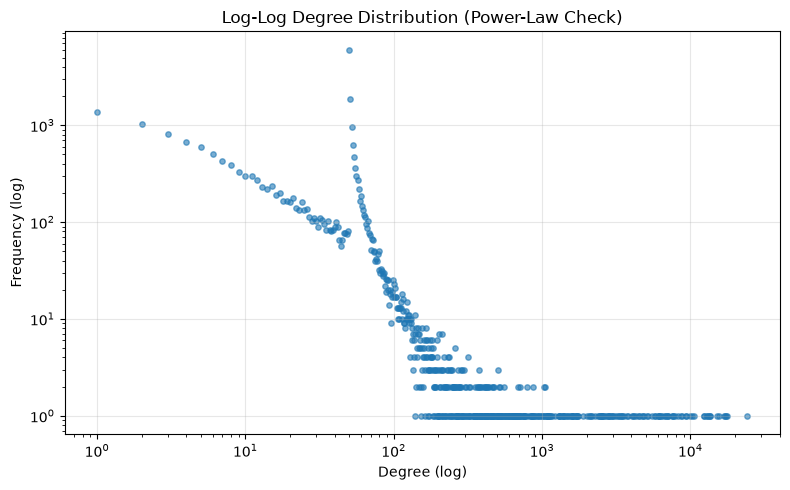

In [166]:
# Log-log degree distribution (power-law check)
unique_degrees, counts = np.unique(degrees, return_counts=True)

plt.figure(figsize=(8, 5))
plt.scatter(unique_degrees, counts, s=15, alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.title("Log-Log Degree Distribution (Power-Law Check)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "degree_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


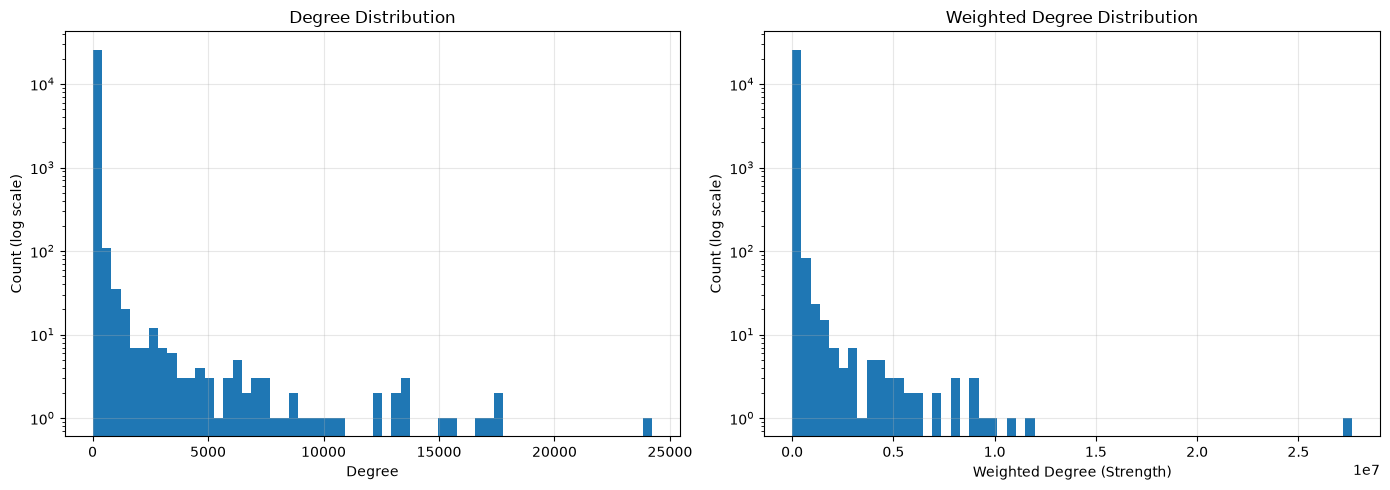

In [167]:
# sort and display top 15 games by degree

degrees = np.array(G.degree())
strength = np.array(G.strength(weights=G.es["weight"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees, bins=60, log=True)
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Degree Distribution")
axes[0].grid(alpha=0.3)

axes[1].hist(strength, bins=60, log=True)
axes[1].set_xlabel("Weighted Degree (Strength)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("Weighted Degree Distribution")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    output_dir / "degree_and_strength_distribution.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [168]:
# calculate weighted degree (strength) for each node

degree_df = pd.DataFrame(
    {
        "id": G.vs["id"],
        "title": G.vs["title"],
        "degree": degrees,
        "weighted_degree": strength,
        "year": G.vs["year"],
        "rating": G.vs["rating"],
        "reviews": G.vs["reviews"],
        "price": G.vs["price"],
        "developer": G.vs["developer"],
    }
)

top_degree = degree_df.sort_values("degree", ascending=False).head(15)
top_strength = degree_df.sort_values("weighted_degree", ascending=False).head(15)

print("TOP 15 GAMES BY DEGREE\n")
display(
    top_degree[
        ["title", "degree", "weighted_degree", "reviews", "rating", "price"]
    ].head(15)
)
print("\nTOP 15 GAMES BY WEIGHTED DEGREE\n")
display(
    top_strength[["title", "weighted_degree", "degree", "reviews", "rating", "price"]].head(
    15
)
)


TOP 15 GAMES BY DEGREE



,title,degree,weighted_degree,reviews,rating,price
22447,Counter-Strike 2,24244,27648197.0,8815087,Very Positive,0.00
19823,Dota 2,17551,10010810.0,2498969,Very Positive,0.00
20006,PUBG: BATTLEGROUNDS,17471,10951791.0,2557944,Mixed,0.00
12657,Grand Theft Auto V Legacy,17023,11792580.0,1990556,Very Positive,0.00
723,Terraria,16841,9176385.0,1409473,Overwhelmingly Positive,4.99
1217,Cyberpunk 2077,15596,8190333.0,844921,Very Positive,20.99
17272,Team Fortress 2,15028,9171913.0,1161472,Very Positive,0.00
19452,Left 4 Dead 2,13643,8147543.0,963983,Overwhelmingly Positive,1.99
13338,The Witcher 3: Wild Hunt,13528,7943872.0,835349,Overwhelmingly Positive,3.99
16664,Stardew Valley,13358,5835435.0,886195,Overwhelmingly Positive,8.99



TOP 15 GAMES BY WEIGHTED DEGREE



,title,weighted_degree,degree,reviews,rating,price
22447,Counter-Strike 2,27648197.0,24244,8815087,Very Positive,0.00
12657,Grand Theft Auto V Legacy,11792580.0,17023,1990556,Very Positive,0.00
20006,PUBG: BATTLEGROUNDS,10951791.0,17471,2557944,Mixed,0.00
19823,Dota 2,10010810.0,17551,2498969,Very Positive,0.00
15243,Tom Clancy's Rainbow Six® Siege X,9517977.0,12978,1398584,Very Positive,0.00
723,Terraria,9176385.0,16841,1409473,Overwhelmingly Positive,4.99
17272,Team Fortress 2,9171913.0,15028,1161472,Very Positive,0.00
16330,Garry's Mod,9065099.0,12397,1159707,Overwhelmingly Positive,4.99
1217,Cyberpunk 2077,8190333.0,15596,844921,Very Positive,20.99
19452,Left 4 Dead 2,8147543.0,13643,963983,Overwhelmingly Positive,1.99


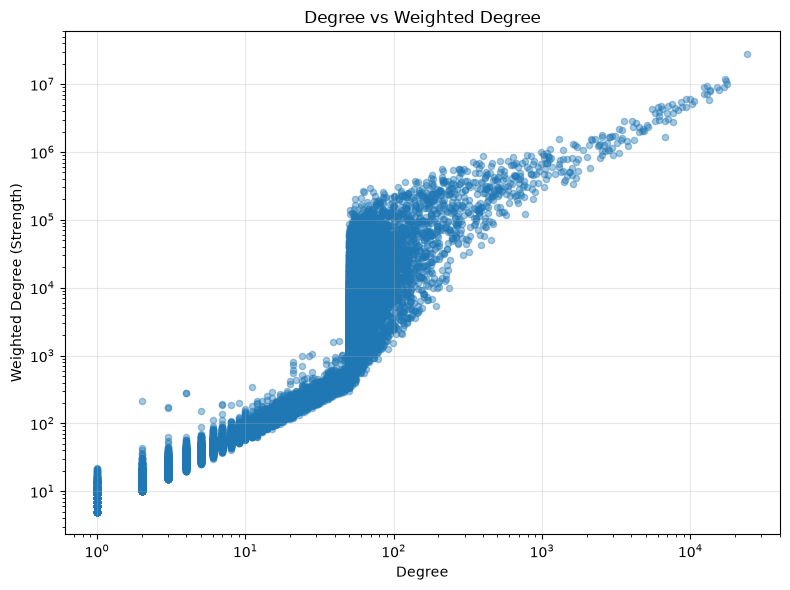

Correlation between degree and weighted degree: 0.951


In [169]:
# plot relationship between degree and weighted degree

plt.figure(figsize=(8, 6))
plt.scatter(degrees, strength, alpha=0.4, s=20)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Weighted Degree (Strength)")
plt.title("Degree vs Weighted Degree")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "degree_vs_strength_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

corr = np.corrcoef(degrees, strength)[0, 1]
print(f"Correlation between degree and weighted degree: {corr:.3f}")

## 6. Clustering Analysis
Clustering coefficients measure how interconnected a node's neighbors are. A high clustering coefficient indicates tight-knit communities (e.g., fans of one game also playing each other's games). We calculate both global and local clustering coefficients.

Global clustering coefficient: 0.016333
Mean local clustering coefficient: 0.737441
Median local clustering coefficient: 0.792157
Max local clustering coefficient: 1.000000


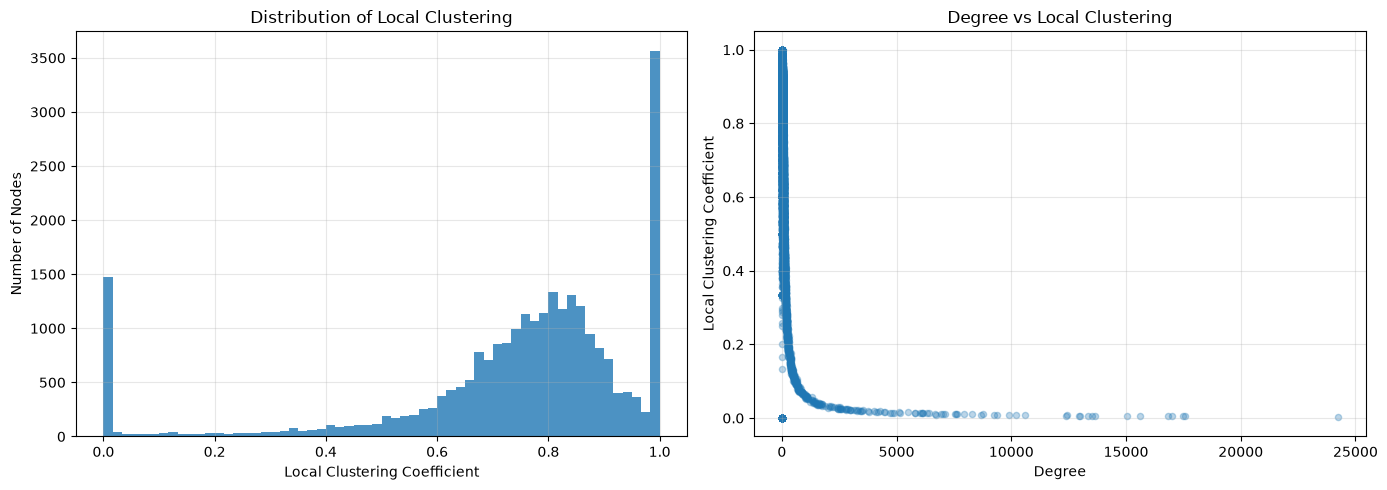

In [170]:
# compute pagerank centrality

global_clustering = G.transitivity_undirected()
local_clustering = np.array(G.transitivity_local_undirected(mode="zero"))

print(f"Global clustering coefficient: {global_clustering:.6f}")
print(f"Mean local clustering coefficient: {local_clustering.mean():.6f}")
print(f"Median local clustering coefficient: {np.median(local_clustering):.6f}")
print(f"Max local clustering coefficient: {local_clustering.max():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(local_clustering, bins=60, range=(0, 1), alpha=0.8)
axes[0].set_xlabel("Local Clustering Coefficient")
axes[0].set_ylabel("Number of Nodes")
axes[0].set_title("Distribution of Local Clustering")
axes[0].grid(alpha=0.3)

axes[1].scatter(degrees, local_clustering, alpha=0.3, s=20)
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Local Clustering Coefficient")
axes[1].set_title("Degree vs Local Clustering")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "clustering_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [171]:
# calculate local and global clustering coefficients

clustering_df = degree_df.copy()
clustering_df["local_clustering"] = local_clustering

top_clustering = clustering_df.sort_values("local_clustering", ascending=False).head(15)

print("TOP 15 GAMES BY LOCAL CLUSTERING\n")
display(
    top_clustering[
    ["title", "degree", "local_clustering", "weighted_degree", "reviews", "rating"]
].head(15)
)


TOP 15 GAMES BY LOCAL CLUSTERING



,title,degree,local_clustering,weighted_degree,reviews,rating
25991,Cube Defense,10,1.0,103.0,69,Mixed
7264,乡间,2,1.0,19.0,91,Mostly Positive
7270,Zombie Survivors,3,1.0,38.0,73,Mixed
7275,World Titans War,9,1.0,79.0,96,Mixed
7283,INHUMAN,4,1.0,34.0,109,Mixed
7284,Water Physics Simulation,10,1.0,118.0,91,Very Positive
7192,Burn Me Alive,3,1.0,17.0,54,Mixed
7195,Heat Death,3,1.0,20.0,65,Very Positive
7292,The Ditty of Carmeana,7,1.0,41.0,58,Very Positive
7298,Dynamic Dungeons Editor,9,1.0,74.0,200,Mixed


## 7. Connected Components
We analyze the network to see if it's fully connected or broken into isolated subgraphs. We find that a single 'giant component' dominates the network, encompassing almost all the games.

In [172]:
# analyze connected components in the graph

# Connected Components Analysis

components = G.connected_components()

component_sizes = np.array(sorted(components.sizes(), reverse=True))

num_components = len(component_sizes)
largest_component_size = component_sizes[0]

print("=== CONNECTED COMPONENT ANALYSIS ===")
print(f"Number of components : {num_components:,}")
print(f"Largest component    : {largest_component_size:,}")
print(f"Smallest component   : {component_sizes[-1]:,}")

print("\nTop 10 component sizes:")
print(component_sizes[:10])

=== CONNECTED COMPONENT ANALYSIS ===
Number of components : 3
Largest component    : 25,992
Smallest component   : 2

Top 10 component sizes:
[25992     2     2]


## 8. PageRank & Communities
We calculate **PageRank** to find the most influential games and use the **Louvain multilevel algorithm** to detect distinct communities (clusters of heavily interconnected games).

In [173]:
# extract the largest connected component

degree_centrality = np.array(G.degree()) / (G.vcount() - 1)

pagerank = np.array(G.pagerank(weights=G.es["weight"]))

centrality_df = pd.DataFrame(
    {
        "title": G.vs["title"],
        "degree": degrees,
        "degree_centrality": degree_centrality,
        "pagerank": pagerank,
    }
)

top_degree_centrality = centrality_df.sort_values(
    "degree_centrality", ascending=False
).head(10)

top_pagerank = centrality_df.sort_values("pagerank", ascending=False).head(10)

print("TOP 10 BY DEGREE CENTRALITY")
display(top_degree_centrality)

print("\nTOP 10 BY PAGERANK")
display(top_pagerank)

TOP 10 BY DEGREE CENTRALITY


,title,degree,degree_centrality,pagerank
22447,Counter-Strike 2,24244,0.932641,0.021589
19823,Dota 2,17551,0.675168,0.009841
20006,PUBG: BATTLEGROUNDS,17471,0.672091,0.009695
12657,Grand Theft Auto V Legacy,17023,0.654857,0.009284
723,Terraria,16841,0.647855,0.009787
1217,Cyberpunk 2077,15596,0.599962,0.008222
17272,Team Fortress 2,15028,0.578111,0.008397
19452,Left 4 Dead 2,13643,0.524832,0.007135
13338,The Witcher 3: Wild Hunt,13528,0.520408,0.006880
16664,Stardew Valley,13358,0.513868,0.007220



TOP 10 BY PAGERANK


,title,degree,degree_centrality,pagerank
22447,Counter-Strike 2,24244,0.932641,0.021589
19823,Dota 2,17551,0.675168,0.009841
723,Terraria,16841,0.647855,0.009787
20006,PUBG: BATTLEGROUNDS,17471,0.672091,0.009695
12657,Grand Theft Auto V Legacy,17023,0.654857,0.009284
17272,Team Fortress 2,15028,0.578111,0.008397
1217,Cyberpunk 2077,15596,0.599962,0.008222
16664,Stardew Valley,13358,0.513868,0.007220
19452,Left 4 Dead 2,13643,0.524832,0.007135
13338,The Witcher 3: Wild Hunt,13528,0.520408,0.006880


In [174]:
# detect communities using the louvain method

communities = G.community_multilevel(weights=G.es["weight"], return_levels=False)

community_sizes = sorted([len(c) for c in communities], reverse=True)

print(f"Number of communities: {len(communities)}")
print("Top 10 community sizes:")
print(community_sizes[:10])

membership = []

for community_id, community in enumerate(communities):
    for vertex in community:
        membership.append((vertex, community_id))

membership_df = pd.DataFrame(membership, columns=["vertex", "community"])

membership_df["title"] = [G.vs[vertex]["title"] for vertex in membership_df["vertex"]]

print("\nCommunity membership sample:")
display(membership_df.head(20))

Number of communities: 27
Top 10 community sizes:
[7445, 7036, 4692, 2693, 2660, 574, 400, 322, 42, 33]

Community membership sample:


,vertex,community,title
0,0,0,Crown Trick
1,1,0,"Cook, Serve, Delicious! 3?!"
2,2,0,Zengeon
3,4,0,Tower of Origin2-Worm's Nest
4,8,0,东方雪莲华 ～ Abyss Soul Lotus.
5,12,0,Clam Man
6,14,0,Foregone
7,19,0,Koi
8,22,0,Where the Bees Make Honey
9,23,0,KUNAI


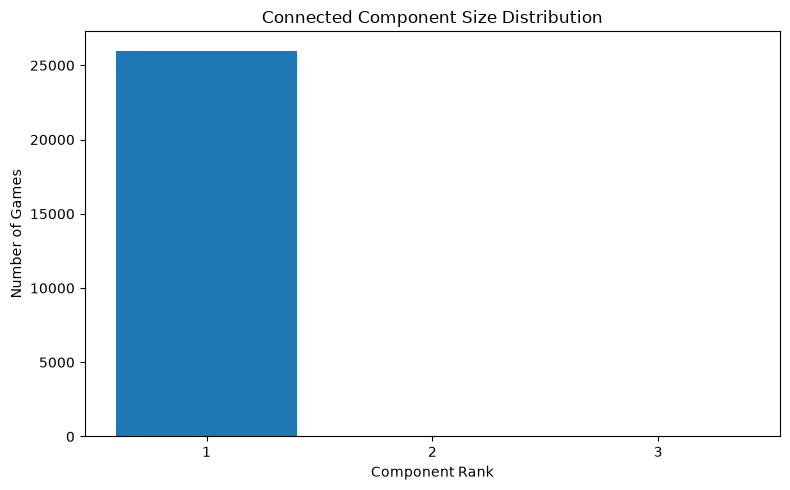

In [175]:
# extract unique genres and prepare for analysis

plt.figure(figsize=(8, 5))

component_ranks = np.arange(1, len(component_sizes) + 1)

plt.bar(component_ranks, component_sizes)

plt.xlabel("Component Rank")
plt.ylabel("Number of Games")
plt.title("Connected Component Size Distribution")

plt.xticks(component_ranks)

plt.tight_layout()

plt.savefig(
    output_dir / "component_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [176]:
# compute average network metrics per genre

largest_component_ratio = largest_component_size / G.vcount()

print(f"Largest component contains " f"{largest_component_ratio:.2%} of all games.")

Largest component contains 99.98% of all games.


## 9. Genre Analysis
We analyze the distribution of game genres in the network. This helps us understand which types of games are more central or influential in the co-review network. We also look at the top genres by average weighted degree to see if certain genres tend to have more interconnected games.

In [177]:
# load original json to map genre ids to names

GENRE_DATA_PATH = "../data/steam_all_2005.json"

with open(GENRE_DATA_PATH, "r", encoding="utf-8") as f:
    genre_data = json.load(f)

print("Available fields:", genre_data.keys())

Available fields: dict_keys(['ratings', 'genres', 'tags', 'games', 'meta'])


In [178]:
# define mapping of genre ids to string labels

genre_mapping = {
    i: genre
    for i, genre in enumerate(genre_data["genres"])
}

print(genre_mapping)

{0: 'Indie', 1: 'Action', 2: 'Casual', 3: 'Adventure', 4: 'Simulation', 5: 'Strategy', 6: 'RPG', 7: 'Early Access', 8: 'Free To Play', 9: 'Sports', 10: 'Racing', 11: 'Massively Multiplayer', 12: 'Utilities', 13: 'Design & Illustration', 14: 'Violent', 15: 'Animation & Modeling', 16: 'Education', 17: 'Video Production', 18: 'Gore', 19: 'Game Development', 20: 'Audio Production', 21: 'Software Training', 22: 'Photo Editing', 23: 'Nudity', 24: 'Web Publishing', 25: 'Sexual Content', 26: 'Accounting', 27: 'Movie', 28: 'Documentary', 29: 'Episodic', 30: 'Short', 31: 'Tutorial', 32: '360 Video'}


In [179]:
# translate genre ids to names for each node

G.vs["genres"] = [
    [genre_mapping[g] for g in node.get("genres", [])]
    for node in nodes
]

print(G.vs[0]["title"])
print(G.vs[0]["genres"])

Crown Trick
['Adventure', 'Indie', 'RPG', 'Strategy']


In [180]:
# prepare genre data for analysis by flattening lists

genre_rows = []

for i, node in enumerate(nodes):
    for genre in G.vs[i]["genres"]:
        genre_rows.append({
            "node_index": i,
            "title": node["title"],
            "genre": genre,
            "degree": degrees[i],
            "strength": strength[i],
            "clustering": local_clustering[i],
            "pagerank": pagerank[i],
            "reviews": node["reviews"]
        })

genre_df = pd.DataFrame(genre_rows)

print(f"Genre-game records: {len(genre_df):,}")
display(genre_df.head())

Genre-game records: 74,210


,node_index,title,genre,degree,strength,clustering,pagerank,reviews
0,0,Crown Trick,Adventure,75,14851.0,0.623784,0.000041,5263
1,0,Crown Trick,Indie,75,14851.0,0.623784,0.000041,5263
2,0,Crown Trick,RPG,75,14851.0,0.623784,0.000041,5263
3,0,Crown Trick,Strategy,75,14851.0,0.623784,0.000041,5263
4,1,"Cook, Serve, Delicious! 3?!",Action,57,4912.0,0.724937,0.000032,2159


In [181]:
# group by genre to calculate average metrics

genre_summary = (
    genre_df
    .groupby("genre")
    .agg(
        games=("node_index", "nunique"),
        avg_degree=("degree", "mean"),
        avg_strength=("strength", "mean"),
        avg_clustering=("clustering", "mean"),
        avg_pagerank=("pagerank", "mean"),
        avg_reviews=("reviews", "mean")
    )
    .sort_values("games", ascending=False)
)

genre_summary

,games,avg_degree,avg_strength,avg_clustering,avg_pagerank,avg_reviews
genre,,,,,,
Indie,17841,52.510678,12255.585729,0.741214,0.000031,3088.765540
Action,11086,83.789374,37354.607974,0.754668,0.000048,8527.736875
Adventure,11019,64.356475,20418.252382,0.718717,0.000037,5042.456212
Casual,8588,44.347462,8394.950279,0.739446,0.000027,2169.553796
Simulation,6122,58.316400,16338.098661,0.749227,0.000034,4552.922574
RPG,5682,87.572510,30086.458113,0.717556,0.000049,6232.469025
Strategy,5670,57.091887,14593.473545,0.731166,0.000033,4201.713757
Free To Play,2408,98.578073,50544.110880,0.780489,0.000059,12978.754153
Early Access,1707,51.937903,14776.076157,0.787390,0.000031,3828.351494


In [182]:
# calculate same-genre vs cross-genre edge weights

edge_list = G.get_edgelist()

same_genre_edges = 0
cross_genre_edges = 0

same_genre_weight = 0
cross_genre_weight = 0

for (source, target), weight in zip(edge_list, weights):
    source_genres = set(G.vs[source]["genres"])
    target_genres = set(G.vs[target]["genres"])

    if source_genres.intersection(target_genres):
        same_genre_edges += 1
        same_genre_weight += weight
    else:
        cross_genre_edges += 1
        cross_genre_weight += weight

total_edges = same_genre_edges + cross_genre_edges
total_weight = same_genre_weight + cross_genre_weight

print("=== GENRE MIXING ===")

print(f"Same-genre edges   : {same_genre_edges:,}")
print(f"Cross-genre edges  : {cross_genre_edges:,}")

print(f"Same-genre edge %  : {same_genre_edges / total_edges:.2%}")
print(f"Cross-genre edge % : {cross_genre_edges / total_edges:.2%}")

print(f"\nSame-genre weight  : {same_genre_weight:,.0f}")
print(f"Cross-genre weight : {cross_genre_weight:,.0f}")

print(f"Same-genre weight % : {same_genre_weight / total_weight:.2%}")
print(f"Cross-genre weight %: {cross_genre_weight / total_weight:.2%}")

=== GENRE MIXING ===
Same-genre edges   : 644,492
Cross-genre edges  : 216,740
Same-genre edge %  : 74.83%
Cross-genre edge % : 25.17%

Same-genre weight  : 221,478,742
Cross-genre weight : 72,360,179
Same-genre weight % : 75.37%
Cross-genre weight %: 24.63%


In [183]:
# filter out genres with fewer than 100 games

genre_filtered = genre_summary[
    genre_summary["games"] >= 100
]

genre_mixing = []

for genre in genre_filtered.index:
    genre_vertices = [
        v.index
        for v in G.vs
        if genre in v["genres"]
    ]

    total_incident_edges = 0
    same_genre_edges = 0

    for vertex in genre_vertices:
        for edge_id in G.incident(vertex):
            edge = G.es[edge_id]

            neighbor = (
                edge.target
                if edge.source == vertex
                else edge.source
            )

            total_incident_edges += 1

            if genre in G.vs[neighbor]["genres"]:
                same_genre_edges += 1

    genre_mixing.append({
        "genre": genre,
        "games": len(genre_vertices),
        "total_edges": total_incident_edges,
        "same_genre_edges": same_genre_edges,
        "same_genre_ratio": (
            same_genre_edges / total_incident_edges
            if total_incident_edges > 0
            else 0
        )
    })

genre_mixing_df = (
    pd.DataFrame(genre_mixing)
    .sort_values("same_genre_ratio", ascending=False)
)

display(genre_mixing_df)

,genre,games,total_edges,same_genre_edges,same_genre_ratio
1,Action,11086,928889,565418,0.608704
0,Indie,17841,936843,539456,0.575823
2,Adventure,11019,709144,336422,0.474406
5,RPG,5682,497587,199226,0.400384
6,Strategy,5670,323711,118758,0.366864
4,Simulation,6122,357013,123862,0.346940
3,Casual,8588,380856,116486,0.305853
7,Free To Play,2408,237376,55032,0.231835
10,Racing,939,45094,6834,0.151550
11,Massively Multiplayer,848,101621,13410,0.131961


In [184]:
# map nodes to their assigned communities

community_membership = communities.membership

genre_df["community"] = genre_df["node_index"].map(
    dict(enumerate(community_membership))
)

print(genre_df[["title", "genre", "community"]].head(10))

                         title       genre  community
0                  Crown Trick   Adventure          0
1                  Crown Trick       Indie          0
2                  Crown Trick         RPG          0
3                  Crown Trick    Strategy          0
4  Cook, Serve, Delicious! 3?!      Action          0
5  Cook, Serve, Delicious! 3?!       Indie          0
6  Cook, Serve, Delicious! 3?!  Simulation          0
7  Cook, Serve, Delicious! 3?!    Strategy          0
8                      Zengeon      Action          0
9                      Zengeon   Adventure          0


In [185]:
# create a crosstab of communities vs genres

community_genre = pd.crosstab(
    genre_df["community"],
    genre_df["genre"]
)

display(community_genre)

genre,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Early Access,Education,Free To Play,...,Racing,Sexual Content,Simulation,Software Training,Sports,Strategy,Utilities,Video Production,Violent,Web Publishing
community,,,,,,,,,,,,,,,,,,,,,
0,0,3006,3678,12,6,2059,13,316,4,216,...,57,11,979,3,82,1236,24,5,9,3
1,2,3476,2574,61,30,2822,72,645,26,1273,...,623,16,2047,34,665,1476,102,42,71,18
2,0,2443,1968,46,19,1868,56,443,26,777,...,170,8,1294,5,236,569,89,28,27,23
3,0,1366,1522,1,0,561,1,15,1,48,...,49,2,129,1,18,199,5,0,11,1
4,0,163,197,0,0,130,0,29,0,9,...,15,0,103,0,32,69,1,0,0,0
5,0,536,523,2,2,385,6,257,1,59,...,19,0,1340,0,96,1951,6,1,4,0
6,0,48,147,0,0,191,0,2,0,0,...,2,0,66,0,2,38,0,0,0,0
7,0,14,343,0,0,463,0,0,0,25,...,1,0,76,0,2,53,0,0,0,0
8,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,4,0,0,0,0


In [186]:
# convert crosstab to percentage distribution

community_genre_pct = community_genre.div(
    community_genre.sum(axis=1),
    axis=0
) * 100

display(
    community_genre_pct.round(2)
)

genre,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Early Access,Education,Free To Play,...,Racing,Sexual Content,Simulation,Software Training,Sports,Strategy,Utilities,Video Production,Violent,Web Publishing
community,,,,,,,,,,,,,,,,,,,,,
0,0.00,15.58,19.06,0.06,0.03,10.67,0.07,1.64,0.02,1.12,...,0.30,0.06,5.07,0.02,0.42,6.40,0.12,0.03,0.05,0.02
1,0.01,14.99,11.10,0.26,0.13,12.17,0.31,2.78,0.11,5.49,...,2.69,0.07,8.83,0.15,2.87,6.36,0.44,0.18,0.31,0.08
2,0.00,17.17,13.83,0.32,0.13,13.13,0.39,3.11,0.18,5.46,...,1.19,0.06,9.10,0.04,1.66,4.00,0.63,0.20,0.19,0.16
3,0.00,23.23,25.88,0.02,0.00,9.54,0.02,0.26,0.02,0.82,...,0.83,0.03,2.19,0.02,0.31,3.38,0.09,0.00,0.19,0.02
4,0.00,14.85,17.94,0.00,0.00,11.84,0.00,2.64,0.00,0.82,...,1.37,0.00,9.38,0.00,2.91,6.28,0.09,0.00,0.00,0.00
5,0.00,6.98,6.81,0.03,0.03,5.02,0.08,3.35,0.01,0.77,...,0.25,0.00,17.46,0.00,1.25,25.42,0.08,0.01,0.05,0.00
6,0.00,4.80,14.70,0.00,0.00,19.10,0.00,0.20,0.00,0.00,...,0.20,0.00,6.60,0.00,0.20,3.80,0.00,0.00,0.00,0.00
7,0.00,1.08,26.38,0.00,0.00,35.62,0.00,0.00,0.00,1.92,...,0.08,0.00,5.85,0.00,0.15,4.08,0.00,0.00,0.00,0.00
8,0.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,40.00,0.00,0.00,0.00,0.00


In [187]:
# identify dominant genres for each community

top_genres_per_community = []

for community_id in community_genre_pct.index:
    top_3 = (
        community_genre_pct.loc[community_id]
        .sort_values(ascending=False)
        .head(3)
    )

    top_genres_per_community.append({
        "community": community_id,
        "community_size": communities.sizes()[community_id],
        "top_genre_1": top_3.index[0],
        "share_1": top_3.iloc[0],
        "top_genre_2": top_3.index[1],
        "share_2": top_3.iloc[1],
        "top_genre_3": top_3.index[2],
        "share_3": top_3.iloc[2]
    })

community_genre_summary = pd.DataFrame(
    top_genres_per_community
)

display(
    community_genre_summary.sort_values(
        "community_size",
        ascending=False
    )
)

,community,community_size,top_genre_1,share_1,top_genre_2,share_2,top_genre_3,share_3
1,1,7445,Indie,22.654364,Action,14.987927,Casual,12.167989
0,0,7036,Indie,25.347150,Adventure,19.056995,Action,15.575130
2,2,4692,Indie,24.518487,Action,17.172782,Adventure,13.833825
5,5,2693,Strategy,25.416884,Indie,21.560709,Simulation,17.457009
3,3,2660,Indie,27.546336,Adventure,25.879952,Action,23.227342
7,7,574,Casual,35.615385,Adventure,26.384615,Indie,22.846154
6,6,400,Indie,26.600000,RPG,23.800000,Casual,19.100000
4,4,322,Indie,24.043716,Adventure,17.941712,Action,14.845173
19,19,42,Simulation,22.826087,Indie,22.826087,Casual,22.282609
10,10,33,Adventure,88.571429,Casual,8.571429,Action,2.857143


In [188]:
# print our main findings regarding genres

same_genre_edge_ratio = same_genre_edges / total_edges
same_genre_weight_ratio = same_genre_weight / total_weight

top_genres_degree = (
    genre_filtered
    .sort_values("avg_degree", ascending=False)
    .head(5)
)

top_genres_clustering = (
    genre_filtered
    .sort_values("avg_clustering", ascending=False)
    .head(5)

)

large_communities = (
    community_genre_summary[
        community_genre_summary["community_size"] >= 100
    ]
    .sort_values("community_size", ascending=False)
)

print("=== FINAL GENRE FINDINGS ===")

print(
    f"Same-genre edges: "
    f"{same_genre_edge_ratio:.2%}"
)

print(
    f"Same-genre edge weight: "
    f"{same_genre_weight_ratio:.2%}"
)

print("\nTop genres by average degree:")
display(
    top_genres_degree[
        ["games", "avg_degree", "avg_strength", "avg_clustering"]
    ]
)

print("\nTop genres by average clustering:")
display(
    top_genres_clustering[
        ["games", "avg_degree", "avg_strength", "avg_clustering"]
    ]
)

print("\nLarge communities and their dominant genres:")
display(large_communities)

=== FINAL GENRE FINDINGS ===
Same-genre edges: 0.04%
Same-genre edge weight: 75.37%

Top genres by average degree:


,games,avg_degree,avg_strength,avg_clustering
genre,,,,
Massively Multiplayer,848,119.836085,62518.003538,0.781476
Animation & Modeling,122,112.032787,55603.745902,0.828664
Design & Illustration,148,99.101351,45576.614865,0.832172
Free To Play,2408,98.578073,50544.110880,0.780489
RPG,5682,87.572510,30086.458113,0.717556



Top genres by average clustering:


,games,avg_degree,avg_strength,avg_clustering
genre,,,,
Utilities,227,75.110132,30762.863436,0.843290
Design & Illustration,148,99.101351,45576.614865,0.832172
Animation & Modeling,122,112.032787,55603.745902,0.828664
Racing,939,48.023429,12935.226837,0.794765
Violent,122,23.000000,838.950820,0.793344



Large communities and their dominant genres:


,community,community_size,top_genre_1,share_1,top_genre_2,share_2,top_genre_3,share_3
1,1,7445,Indie,22.654364,Action,14.987927,Casual,12.167989
0,0,7036,Indie,25.347150,Adventure,19.056995,Action,15.575130
2,2,4692,Indie,24.518487,Action,17.172782,Adventure,13.833825
5,5,2693,Strategy,25.416884,Indie,21.560709,Simulation,17.457009
3,3,2660,Indie,27.546336,Adventure,25.879952,Action,23.227342
7,7,574,Casual,35.615385,Adventure,26.384615,Indie,22.846154
6,6,400,Indie,26.600000,RPG,23.800000,Casual,19.100000
4,4,322,Indie,24.043716,Adventure,17.941712,Action,14.845173


## 10. Metadata Correlation
Finally, we build a pandas DataFrame to correlate our network centralities (like weighted degree) against the real-world Steam metadata (price, reviews, year). We discover that the number of reviews strongly correlates with centrality, while the price does not.

Average metadata by degree band

degree_band    price      reviews  weighted_degree
        low 4.296477   149.259765        35.380662
     medium 4.945139   590.357653      1394.567164
       high 5.681187  1827.601842      5032.716968
  very_high 6.448691 22293.458164     98742.095878

Correlation price vs weighted_degree: 0.026

Correlation reviews vs weighted_degree: 0.922

Correlation year vs weighted_degree: -0.045

Top 15 high-degree games by reviews and price:
                            title  degree  weighted_degree  reviews  price                  rating
                 Counter-Strike 2   24244       27648197.0  8815087   0.00           Very Positive
                           Dota 2   17551       10010810.0  2498969   0.00           Very Positive
              PUBG: BATTLEGROUNDS   17471       10951791.0  2557944   0.00                   Mixed
        Grand Theft Auto V Legacy   17023       11792580.0  1990556   0.00           Very Positive
                         Terrari

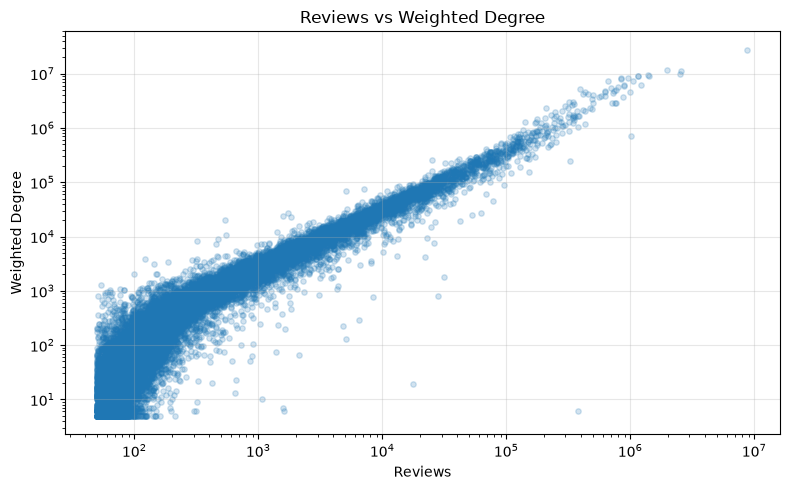

In [189]:
# build a comprehensive dataframe and calculate correlations

metadata_df = pd.DataFrame(
    {
        "title": G.vs["title"],
        "degree": degrees,
        "weighted_degree": strength,
        "year": G.vs["year"],
        "rating": G.vs["rating"],
        "reviews": G.vs["reviews"],
        "price": G.vs["price"],
        "genres": G.vs["genres"],
        "tags": G.vs["tags"],
        "developer": G.vs["developer"],
    }
)

metadata_df["degree"] = pd.to_numeric(metadata_df["degree"], errors="coerce")
metadata_df["weighted_degree"] = pd.to_numeric(
    metadata_df["weighted_degree"], errors="coerce"
)
metadata_df["reviews"] = pd.to_numeric(metadata_df["reviews"], errors="coerce")
metadata_df["price"] = pd.to_numeric(metadata_df["price"], errors="coerce")
metadata_df["year"] = pd.to_numeric(metadata_df["year"], errors="coerce")

metadata_df["degree_band"] = pd.qcut(
    metadata_df["degree"], q=4, labels=["low", "medium", "high", "very_high"]
)

summary = (
    metadata_df.groupby("degree_band")[["price", "reviews", "weighted_degree"]]
    .mean()
    .reset_index()
)
print("Average metadata by degree band\n")
print(summary.to_string(index=False))

corr_price = metadata_df["price"].corr(metadata_df["weighted_degree"])
corr_reviews = metadata_df["reviews"].corr(metadata_df["weighted_degree"])
corr_year = metadata_df["year"].corr(metadata_df["weighted_degree"])

print(f"\nCorrelation price vs weighted_degree: {corr_price:.3f}")
print(f"\nCorrelation reviews vs weighted_degree: {corr_reviews:.3f}")
print(f"\nCorrelation year vs weighted_degree: {corr_year:.3f}")

high_degree = metadata_df.sort_values("degree", ascending=False).head(100)
print("\nTop 15 high-degree games by reviews and price:")
print(
    high_degree[["title", "degree", "weighted_degree", "reviews", "price", "rating"]]
    .head(15)
    .to_string(index=False)
)

plt.figure(figsize=(8, 5))
plt.scatter(metadata_df["reviews"], metadata_df["weighted_degree"], alpha=0.2, s=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Reviews")
plt.ylabel("Weighted Degree")
plt.title("Reviews vs Weighted Degree")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "reviews_vs_weighted_degree.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Final Summary
This section prints out the final project summary and interpretation of our findings, ready to be included in project report

In [191]:
# prepare final statistics and generate a markdown summary

corr_degree_strength = metadata_df["degree"].corr(
    metadata_df["weighted_degree"]
)

corr_reviews_strength = metadata_df["reviews"].corr(
    metadata_df["weighted_degree"]
)

corr_price_strength = metadata_df["price"].corr(
    metadata_df["weighted_degree"]
)

corr_year_strength = metadata_df["year"].corr(
    metadata_df["weighted_degree"]
)

top_degree_titles = top_degree["title"].head(5).tolist()
top_strength_titles = top_strength["title"].head(5).tolist()
top_pagerank_titles = top_pagerank["title"].head(5).tolist()


global_same_genre_edges = 0
global_cross_genre_edges = 0
global_same_genre_weight = 0
global_cross_genre_weight = 0

for edge, weight in zip(G.es, weights):
    source_genres = set(G.vs[edge.source]["genres"])
    target_genres = set(G.vs[edge.target]["genres"])

    if source_genres.intersection(target_genres):
        global_same_genre_edges += 1
        global_same_genre_weight += weight
    else:
        global_cross_genre_edges += 1
        global_cross_genre_weight += weight

same_genre_edge_ratio = (
    global_same_genre_edges /
    (global_same_genre_edges + global_cross_genre_edges)
)

same_genre_weight_ratio = (
    global_same_genre_weight /
    (global_same_genre_weight + global_cross_genre_weight)
)

same_genre_weight_ratio = same_genre_weight / (
    same_genre_weight + cross_genre_weight
)

top_genres_degree = (
    genre_filtered
    .sort_values("avg_degree", ascending=False)
    .head(5)
)

summary_text = f"""
# FINAL SUMMARY

## 1. Network Structure

- **Network type:** {"Directed" if G.is_directed() else "Undirected"}, {"Weighted" if "weight" in G.es.attributes() else "Unweighted"}
- **Number of games (nodes):** {G.vcount():,}
- **Number of connections (edges):** {G.ecount():,}
- **Network density:** {G.density():.6f}
- **Number of connected components:** {num_components}
- **Largest connected component:** {largest_component_size:,} games ({largest_component_ratio:.2%} of the network)

## 2. Degree and Centrality

- **Minimum degree:** {degrees.min():,}
- **Maximum degree:** {degrees.max():,}
- **Mean degree:** {degrees.mean():.2f}
- **Median degree:** {np.median(degrees):.2f}
- **Degree–weighted degree correlation:** {corr_degree_strength:.3f}


{", ".join(top_degree_titles)}


{", ".join(top_strength_titles)}


{", ".join(top_pagerank_titles)}

## 3. Clustering and Community Structure

- **Global clustering coefficient:** {global_clustering:.6f}
- **Mean local clustering coefficient:** {local_clustering.mean():.6f}
- **Detected communities:** {len(communities)}
- **Largest community:** {community_sizes[0]:,} games

## 4. Metadata Relationships

- **Reviews vs weighted degree:** {corr_reviews_strength:.3f}
- **Price vs weighted degree:** {corr_price_strength:.3f}
- **Year vs weighted degree:** {corr_year_strength:.3f}

## 5. Genre Analysis

- **Same-genre connections:** {same_genre_edge_ratio:.2%} of all edges connect games sharing at least one genre.
- **Same-genre connection weight:** {same_genre_weight_ratio:.2%} of total edge weight comes from connections between games sharing at least one genre.
- Among genres with at least 100 games, the highest average network degree is observed for **{top_genres_degree.index[0]}** ({top_genres_degree.iloc[0]["avg_degree"]:.2f}), followed by **{top_genres_degree.index[1]}** ({top_genres_degree.iloc[1]["avg_degree"]:.2f}) and **{top_genres_degree.index[2]}** ({top_genres_degree.iloc[2]["avg_degree"]:.2f}).
- The largest detected communities contain multiple genres rather than being dominated by a single genre.

## 6. Main Findings

- The network is highly concentrated around a small number of highly connected games.
- Almost the entire network belongs to a single giant connected component.
- Degree and weighted degree show a strong positive relationship.
- The number of reviews has a strong positive association with weighted network centrality.
- Price has a very weak relationship with weighted network centrality.
- Release year has a weak relationship with weighted network centrality.
- Genre similarity is associated with network connectivity, with approximately {same_genre_edge_ratio:.1%} of edges connecting games sharing at least one genre.
- Despite this same-genre tendency, the largest communities are genre-diverse rather than being dominated by a single genre.
"""

display(Markdown(summary_text))


# FINAL SUMMARY

## 1. Network Structure

- **Network type:** Undirected, Weighted
- **Number of games (nodes):** 25,996
- **Number of connections (edges):** 861,232
- **Network density:** 0.002549
- **Number of connected components:** 3
- **Largest connected component:** 25,992 games (99.98% of the network)

## 2. Degree and Centrality

- **Minimum degree:** 1
- **Maximum degree:** 24,244
- **Mean degree:** 66.26
- **Median degree:** 50.00
- **Degree–weighted degree correlation:** 0.951


Counter-Strike 2, Dota 2, PUBG: BATTLEGROUNDS, Grand Theft Auto V Legacy, Terraria


Counter-Strike 2, Grand Theft Auto V Legacy, PUBG: BATTLEGROUNDS, Dota 2, Tom Clancy's Rainbow Six® Siege X


Counter-Strike 2, Dota 2, Terraria, PUBG: BATTLEGROUNDS, Grand Theft Auto V Legacy

## 3. Clustering and Community Structure

- **Global clustering coefficient:** 0.016333
- **Mean local clustering coefficient:** 0.737441
- **Detected communities:** 27
- **Largest community:** 7,445 games

## 4. Metadata Relationships

- **Reviews vs weighted degree:** 0.922
- **Price vs weighted degree:** 0.026
- **Year vs weighted degree:** -0.045

## 5. Genre Analysis

- **Same-genre connections:** 74.83% of all edges connect games sharing at least one genre.
- **Same-genre connection weight:** 75.37% of total edge weight comes from connections between games sharing at least one genre.
- Among genres with at least 100 games, the highest average network degree is observed for **Massively Multiplayer** (119.84), followed by **Animation & Modeling** (112.03) and **Design & Illustration** (99.10).
- The largest detected communities contain multiple genres rather than being dominated by a single genre.

## 6. Main Findings

- The network is highly concentrated around a small number of highly connected games.
- Almost the entire network belongs to a single giant connected component.
- Degree and weighted degree show a strong positive relationship.
- The number of reviews has a strong positive association with weighted network centrality.
- Price has a very weak relationship with weighted network centrality.
- Release year has a weak relationship with weighted network centrality.
- Genre similarity is associated with network connectivity, with approximately 74.8% of edges connecting games sharing at least one genre.
- Despite this same-genre tendency, the largest communities are genre-diverse rather than being dominated by a single genre.
